In [2]:
#  data is from  https://archive.ics.uci.edu/dataset/45/heart%2Bdisease

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [3]:
X.head(3) 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0


In [4]:
df = X

In [5]:
y.head(3)

,num
0,0
1,2
2,1


In [6]:
len(X)

303

In [7]:
len(y)

303

In [8]:
import pandas as pd
df = pd.concat([X, y], axis=1)

In [9]:
len(df)

303

In [10]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [11]:
# ============================================================
# Heart Disease: Calibration + Risk-Aware (Bayesian) Decisions
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (brier_score_loss, log_loss, roc_auc_score,
                             accuracy_score)
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from scipy.optimize import minimize


In [12]:
# ---------------------------
# Load & preprocess UCI data
# ---------------------------
# UCI Heart Disease (Cleveland) mirrored CSVs are common; if you download
# from UCI, keep the same column order. Here we assume the standard 14 columns.
cols = [
    "age","sex","cp","trestbps","chol","fbs","restecg","thalach",
    "exang","oldpeak","slope","ca","thal","target"
]


In [13]:
# Ensure expected columns exist; if needed, rename:
df.columns = [c.lower() for c in df.columns]
if 'target' not in df.columns:
    # Some versions call it 'num' where 0=no disease; >=1=disease
    if 'num' in df.columns:
        df['target'] = (df['num'] > 0).astype(int)
    else:
        raise ValueError("Could not find target/num column.")

In [14]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target'],
      dtype='object')

In [15]:
df_temp = df
df = df_temp.dropna()
# Binarize target: 1 = disease present, 0 = no disease
y = df['target'].astype(int).values
X = df.drop(columns=['target'])

In [16]:
# Quick train/val/test split (60/20/20)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)  # Final composition:  0.6 train / 0.2 val / 0.2 test

In [17]:
# A reasonably strong but not overcalibrated baseline; Logistic regression
# using classical method 
base_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, penalty="l2"))
])
base_clf.fit(X_train, y_train)

def eval_probs(y_true, p, name=""):
    print(f"\n== {name} ==")
    print("AUC:", roc_auc_score(y_true, p))
    print("Brier:", brier_score_loss(y_true, p))
    print("LogLoss:", log_loss(y_true, p))

p_val_base = base_clf.predict_proba(X_val)[:, 1]
eval_probs(y_val, p_val_base, "Base (val)")


== Base (val) ==
AUC: 1.0
Brier: 0.016624894728653965
LogLoss: 0.09310458789518887


In [18]:

# ---------------------------
# Now we need to do MODEL Calibration. 
# Please see slides in the lecturer folder explaining about the needs of ML model calibration.  
# Platt scaling (sigmoid) on validation, apply at test time
# ---------------------------
platt = CalibratedClassifierCV(estimator=base_clf, method="sigmoid", cv="prefit")
platt.fit(X_val, y_val)

p_val_platt = platt.predict_proba(X_val)[:, 1]
eval_probs(y_val, p_val_platt, "Platt (val)")


== Platt (val) ==
AUC: 1.0
Brier: 0.016969697118781706
LogLoss: 0.09239222609670125


C:\Users\sunny\anaconda3\envs\gpu_exe\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [19]:
# ---------------------------
# Temperature scaling (binary) on validation
# We scale the *logits* (log-odds) before sigmoid.
# The method details can be seen in the lecture folder. 
# It addresses the issue of miscalibration, where a model's 
# predicted probabilities do not accurately reflect the true 
# likelihood of an event.
# ---------------------------
def logit(p, eps=1e-7):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

class TemperatureScaler:
    def __init__(self):
        self.T_ = 1.0

    def fit(self, p_val, y_val):
        # Optimize T to minimize NLL on validation
        z = logit(p_val)  # logits from base probabilities
        def nll(t):
            T = np.exp(t)  # optimize in log-space to keep T>0
            p = sigmoid(z / T)
            return log_loss(y_val, p)

        res = minimize(nll, x0=np.log(1.0), method="L-BFGS-B")
        self.T_ = float(np.exp(res.x[0]))
        return self

    def transform(self, p):
        z = logit(p)
        return sigmoid(z / self.T_)

temp = TemperatureScaler().fit(p_val_base, y_val)
p_val_temp = temp.transform(p_val_base)
eval_probs(y_val, p_val_temp, f"TempScale T={temp.T_:.3f} (val)")



== TempScale T=0.018 (val) ==
AUC: 1.0
Brier: 1.9834649243152516e-11
LogLoss: 5.749686011809704e-07


# from the above output, the logloss and Brier loss are both much smaller 

In [21]:
# ---------------------------
# Compare on TEST set (before vs after calibration)
# ---------------------------
p_test_base  = base_clf.predict_proba(X_test)[:, 1]
p_test_platt = platt.predict_proba(X_test)[:, 1]
p_test_temp  = temp.transform(p_test_base)

print("\n=== TEST performance ===")
eval_probs(y_test, p_test_base,  "Base (test)")
eval_probs(y_test, p_test_platt, "Platt (test)")
eval_probs(y_test, p_test_temp,  f"TempScale T={temp.T_:.3f} (test)")



=== TEST performance ===

== Base (test) ==
AUC: 1.0
Brier: 0.010344861565115762
LogLoss: 0.0669634526176079

== Platt (test) ==
AUC: 1.0
Brier: 0.0106372188009346
LogLoss: 0.0665199996909929

== TempScale T=0.018 (test) ==
AUC: 1.0
Brier: 3.2192372253891908e-24
LogLoss: 2.3185157497749645e-13


<Figure size 600x500 with 0 Axes>

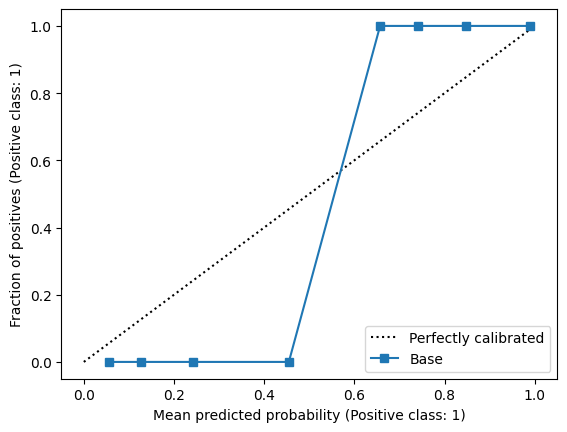

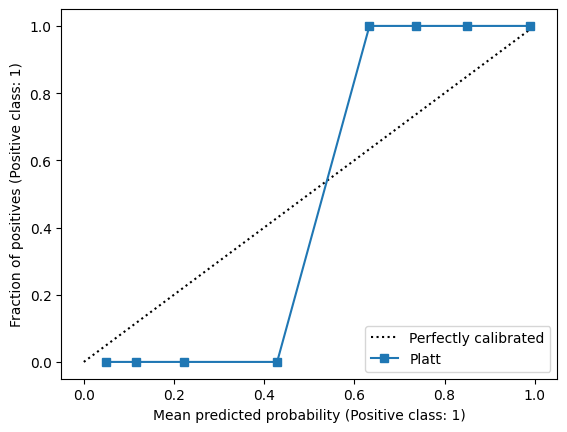

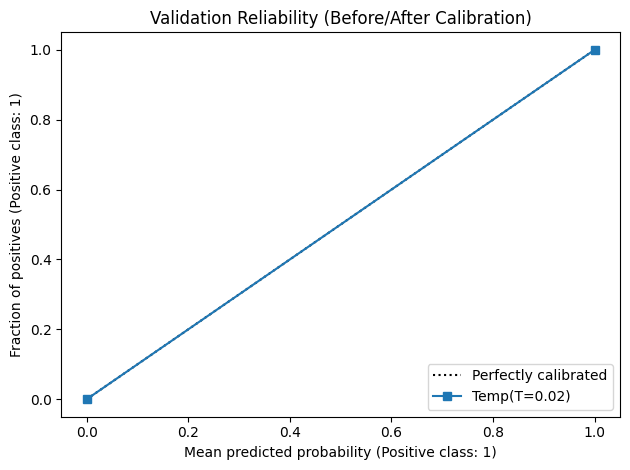

<Figure size 600x500 with 0 Axes>

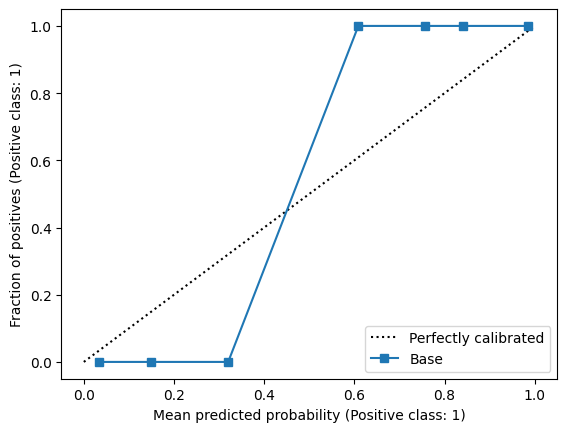

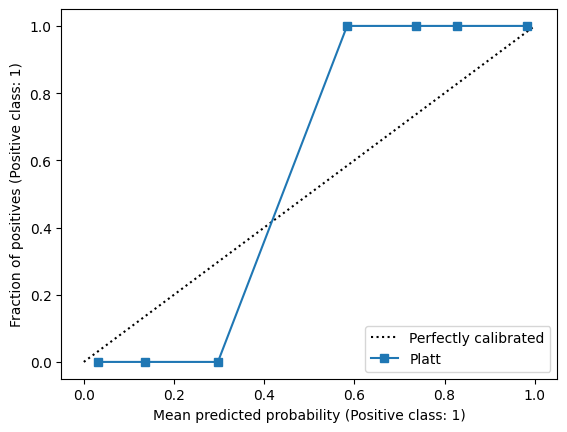

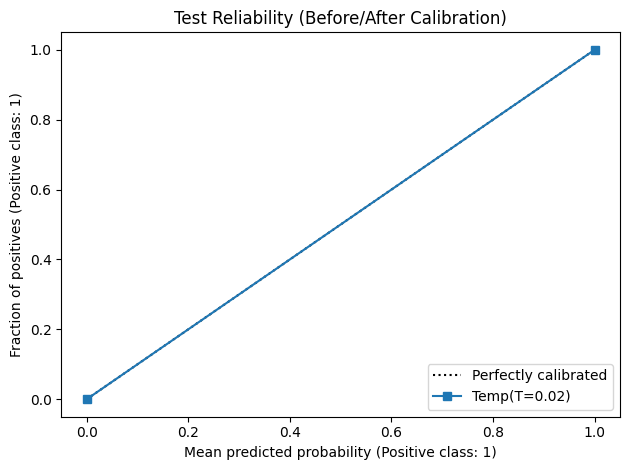

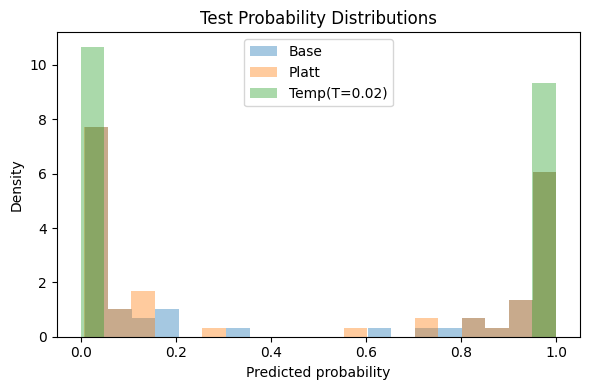

In [22]:
# ---------------------------
# Reliability plots (val & test)
# Calibration plots against before calibration 
# ---------------------------
def reliability_plot(y_true, prob_sets: dict, title):
    plt.figure(figsize=(6,5))
    for label, p in prob_sets.items():
        CalibrationDisplay.from_predictions(y_true, p, n_bins=10, name=label)
    plt.title(title)
    plt.tight_layout()
    plt.show()

reliability_plot(
    y_val,
    {"Base": p_val_base, "Platt": p_val_platt, f"Temp(T={temp.T_:.2f})": p_val_temp},
    "Validation Reliability (Before/After Calibration)"
)
reliability_plot(
    y_test,
    {"Base": p_test_base, "Platt": p_test_platt, f"Temp(T={temp.T_:.2f})": p_test_temp},
    "Test Reliability (Before/After Calibration)"
)

# Optional: histogram of predicted probs
def hist_probs(prob_sets: dict, title):
    plt.figure(figsize=(6,4))
    for label, p in prob_sets.items():
        plt.hist(p, bins=20, alpha=0.4, label=label, density=True)
    plt.xlabel("Predicted probability")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

hist_probs(
    {"Base": p_test_base, "Platt": p_test_platt, f"Temp(T={temp.T_:.2f})": p_test_temp},
    "Test Probability Distributions"
)

In [23]:
# ---------------------------
# 7) Save per-sample probabilities (test set)
# ---------------------------
test_probs = X_test.copy()
test_probs["y_true"] = y_test
test_probs["p_base"] = p_test_base
test_probs["p_platt"] = p_test_platt
test_probs["p_temp"] = p_test_temp
test_probs.to_csv("test_probabilities.csv", index=False)
print("\nSaved: test_probabilities.csv (per-sample probabilities)")
p_base_lst = test_probs["p_base"].tolist()
# ---------------------------
# 8) Bayesian / risk-aware decision making
#    Action a ∈ {Treat, NoTreat} chosen by minimizing expected loss.
#    Personalized cost model using age/sex.
# ---------------------------
def cost_matrix(age, sex):
    """
    Return (C_TP, C_FP, C_FN, C_TN).
    Intuition:
      - C_FN (missed disease) grows with age (higher risk if untreated).
      - C_FP (unnecessary treatment) mildly higher for males or younger patients
        if we (hypothetically) assume higher side-effect disutility.
    NOTE: These numbers are *illustrative only*. Calibrate with domain experts.
    """
    # Base costs
    C_TN = 0.0
    C_TP = 2.0   # treat + disease present (side effects, time, $$)
    # Age scaling (older => missing disease is costlier)
    C_FN = 30.0 + 0.3 * max(age - 50, 0)
    # Slight sex-based difference (example only; be cautious about bias)
    # sex: 1=male, 0=female in this dataset
    C_FP = 5.0 + (1.0 if sex == 1 else 0.5)
    return C_TP, C_FP, C_FN, C_TN

def decision_threshold(C_TP, C_FP, C_FN, C_TN):
    # Treat if p > (C_FP - C_TN)/((C_FP - C_TN) + (C_FN - C_TP))
    num = (C_FP - C_TN)
    den = (C_FP - C_TN) + (C_FN - C_TP)
    thr = num / den
    return np.clip(thr, 0.0, 1.0)

def decide_treat(p, age, sex, costs=None):
    C_TP, C_FP, C_FN, C_TN = costs if costs else cost_matrix(age, sex)
    thr = decision_threshold(C_TP, C_FP, C_FN, C_TN)
    return int(p >= thr), thr  # 1=treat, 0=not treat

# Apply decisions using the BEST-CALIBRATED probs (pick one; here temperature)
chosen_probs = p_test_temp

decisions = []
thresholds = []
# consider age and gender as risk assement parameters
for i, (idx, row) in enumerate(X_test.iterrows()):
    age = row["age"]
    sex = row["sex"]
    act, thr = decide_treat(chosen_probs[i], age, sex, None)
    decisions.append(act)
    thresholds.append(thr)
    
    
risk_df = X_test.copy()
risk_df["y_true"] = y_test
risk_df["p"] = chosen_probs
risk_df["threshold"] = thresholds
risk_df["action_treat"] = decisions
risk_df['p_base'] = p_base_lst
risk_df.to_csv("test_risk_aware_decisions.csv", index=False)
# Each patient has differet thresholds 
print("Saved: test_risk_aware_decisions.csv (personalized thresholds & actions)")

# Quick summary of actions
treat_rate = np.mean(risk_df["action_treat"])
print(f"Treat rate (test, risk-aware): {treat_rate:.3f}")

# Evaluate decision quality in expected loss terms (using our cost model)
def expected_loss_row(y, p, age, sex):
    C_TP, C_FP, C_FN, C_TN = cost_matrix(age, sex)
    # Best action expected loss (Bayes-optimal):
    thr = decision_threshold(C_TP, C_FP, C_FN, C_TN)
    # If treat:
    el_treat = p * C_TP + (1 - p) * C_FP
    # If no treat:
    el_notreat = p * C_FN + (1 - p) * C_TN
    el_opt = min(el_treat, el_notreat)
    return el_opt, thr

els = []
for i, (idx, row) in enumerate(X_test.iterrows()):
    el, thr = expected_loss_row(y_test[i], chosen_probs[i], row["age"], row["sex"])
    els.append(el)
print(f"Average Bayes-optimal expected loss (test): {np.mean(els):.2f}")



Saved: test_probabilities.csv (per-sample probabilities)
Saved: test_risk_aware_decisions.csv (personalized thresholds & actions)
Treat rate (test, risk-aware): 0.467
Average Bayes-optimal expected loss (test): 0.93


In [24]:
X_test.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [25]:
# based on the treatment decision, we can plot the decision against the model outputs
df_final = pd.read_csv("test_risk_aware_decisions.csv")

In [26]:
df_final.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,y_true,p,threshold,action_treat,p_base
0,41,1,2,120,157,0,0,182,0,0.0,1,0.0,3.0,0,0,1.531612e-90,0.176471,0,0.025093
1,49,0,4,130,269,0,0,163,0,0.0,1,0.0,3.0,0,0,1.076671e-89,0.164179,0,0.025951
2,66,1,4,120,302,0,2,151,0,0.4,2,0.0,3.0,0,0,3.556137e-45,0.154639,0,0.140492


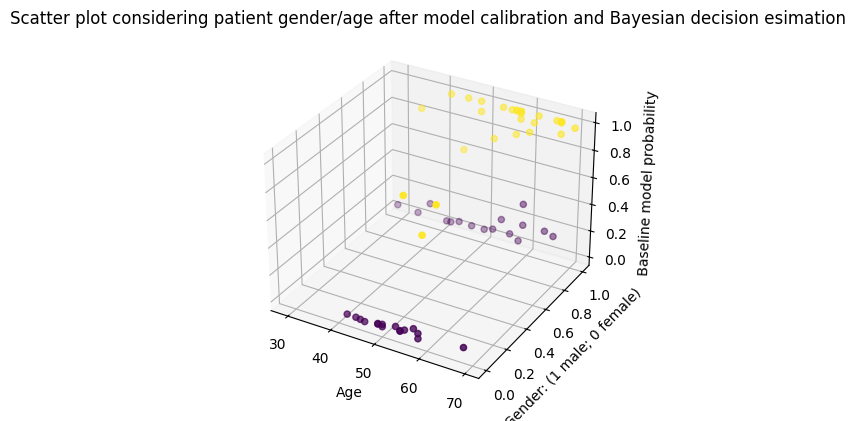

In [31]:
import itertools
#import itertools
#colors = itertools.cycle(["r", "b", "g", "y"])

x = df_final["age"]
y = df_final["sex"]
# note again: set=1 male; sex=0 female
#X, Y = np.meshgrid(x, y)
z = df_final["p_base"]
zz = df_final["action_treat"]
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.scatter(x, y, z, c=zz, marker = 'o', cmap = "viridis")
ax.set_xlabel("Age")
ax.set_ylabel("Gender: (1 male; 0 female)")
ax.set_zlabel("Baseline model probability")
ax.set_title('Scatter plot considering patient gender/age after model calibration and Bayesian decision esimation')
plt.show()


## Short Discussions:  
The above plot shows the relations among age/gender/base model output probability and action decision (yellow is "take treatment"). 
It is obvious that without Bayesian decision approach and model calibration, our decision will be purely based on the baseline model outputs. 
In this case, we will be missing (no action) for the young male group (age < 50) since they have low model output probability for actions. 
On the other side of the spetrcum, looking at the older male group (age >= 50), the treatment decision fits much better with the baseline model outputs since most of the high probability model output patients need finally treatment which aligns with the Bayesian decisions. 

### Conclusions: 
Medical treatment should be considered as a high risk AI application. The final decision should not be purely on the AI model outputs, since the model itself could be over-confident. The model needs to be re-calibrated and then be wrapped up with decision theory and finally the decision is made. 
Looking forward, considering the whole decision procedures from system science perspective, we should also add a feedback loop inside the system for future further enhenceement. This is something which is lacking off in our current medical doctor-patient system. If possible, any follow up information after the patient treatment will be very useful for us to enhence the decision system.  

